# Analise exploratoria inicial - CVLI em Alagoas

Primeira leitura da base de microdados de Crimes Violentos Letais Intencionais (CVLI) em Alagoas, de 2012 a abril de 2026.

Objetivos desta etapa:

- entender estrutura, tipos e problemas de qualidade da base;
- criar variaveis temporais e faixas analiticas;
- observar perfil das vitimas, locais, cidades e instrumentos;
- testar primeiras hipoteses do projeto;
- levantar pistas para insights acionaveis e modelagem futura.

## 1. Setup

Se algum pacote faltar, rode no terminal do projeto:

```bash
python3 -m pip install -r requirements.txt
```

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)
sns.set_theme(style='whitegrid', palette='viridis')

DATA_PATH = Path('..') / 'cvli-microdados-alagoas-2012-a-abril-de-2026.csv'
DATA_PATH.exists()

True

## 2. Carga dos dados

In [2]:
raw = pd.read_csv(DATA_PATH)
df = raw.copy()

print(f'Registros: {df.shape[0]:,}'.replace(',', '.'))
print(f'Colunas: {df.shape[1]}')
df.head()

Registros: 21.217
Colunas: 14


,ID_CONTROLE,SUBJETIVIDADE,SUBJETIVIDADE COMPLEMENTAR,DATA DO FATO,HORA DO FATO,CIDADE DO FATO,BAIRRO DO FATO,SEXO DA VITIMA,COR/RACA DA VITIMA,IDADE DA VITIMA,INSTRUMENTO UTILIZADO,LOCAL DO FATO,OCUPACAO VITIMA,ESCOLARIDADE VITIMA
0,46,CVLI,Homicídio,03/01/2012,12:30,Maceió,Benedito Bentes,Masculino,NI,24,PAF/B,Local de Trabalho,NI,NI
1,47,CVLI,Homicídio,03/01/2012,13:00,Palmeira dos Índios,Palmeira de Fora,Masculino,Parda,51,BRANCA,Próximo de Casa,Servidor Público,Superior
2,48,CVLI,Homicídio,03/01/2012,13:15,Maceió,Cidade Universitária,Masculino,Amarela,24,PAF,Via Pública,NI,NI
3,63,CVLI,Homicídio,07/01/2012,08:00,União dos Palmares,Zona Rural,Masculino,Parda,NI,ESPANCAMENTO,Vegetação,NI,NI
4,59,CVLI,Homicídio,06/01/2012,13:00,Maceió,Tabuleiro do Martins,Masculino,NI,21,PAF,Via Pública,NI,NI


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 21217 entries, 0 to 21216
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID_CONTROLE                 21217 non-null  int64
 1   SUBJETIVIDADE               21217 non-null  str  
 2   SUBJETIVIDADE COMPLEMENTAR  21217 non-null  str  
 3   DATA DO FATO                21217 non-null  str  
 4   HORA DO FATO                21217 non-null  str  
 5   CIDADE DO FATO              21217 non-null  str  
 6   BAIRRO DO FATO              21217 non-null  str  
 7   SEXO DA VITIMA              21217 non-null  str  
 8   COR/RACA DA VITIMA          21217 non-null  str  
 9   IDADE DA VITIMA             21217 non-null  str  
 10  INSTRUMENTO UTILIZADO       21217 non-null  str  
 11  LOCAL DO FATO               21217 non-null  str  
 12  OCUPACAO VITIMA             21217 non-null  str  
 13  ESCOLARIDADE VITIMA         21217 non-null  str  
dtypes: int64(1), str(

## 3. Limpeza inicial e variaveis derivadas

A base usa `NI` para valores nao informados. Aqui `NI` vira `NaN` para analise correta de faltantes.

In [4]:
# Padroniza strings e transforma NI em ausente.
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype(str).str.strip()
    df[col] = df[col].replace({'NI': pd.NA, 'nan': pd.NA, '': pd.NA})

df['data_fato'] = pd.to_datetime(df['DATA DO FATO'], format='%d/%m/%Y', errors='coerce')
hora = pd.to_datetime(df['HORA DO FATO'], format='%H:%M', errors='coerce')
df['hora'] = hora.dt.hour
df['minuto'] = hora.dt.minute
df['idade'] = pd.to_numeric(df['IDADE DA VITIMA'], errors='coerce')

df['ano'] = df['data_fato'].dt.year
df['mes'] = df['data_fato'].dt.month
df['ano_mes'] = df['data_fato'].dt.to_period('M').dt.to_timestamp()
df['dia_semana_num'] = df['data_fato'].dt.dayofweek
df['dia_semana'] = df['dia_semana_num'].map({
    0: 'Segunda', 1: 'Terca', 2: 'Quarta', 3: 'Quinta',
    4: 'Sexta', 5: 'Sabado', 6: 'Domingo'
})
df['fim_de_semana'] = df['dia_semana_num'].isin([5, 6])

df['periodo_dia'] = pd.cut(
    df['hora'],
    bins=[-1, 5, 11, 17, 23],
    labels=['Madrugada (0-5)', 'Manha (6-11)', 'Tarde (12-17)', 'Noite (18-23)']
)

df['faixa_etaria'] = pd.cut(
    df['idade'],
    bins=[-1, 11, 17, 24, 29, 39, 59, np.inf],
    labels=['0-11', '12-17', '18-24', '25-29', '30-39', '40-59', '60+']
)

df[['data_fato', 'hora', 'idade', 'ano', 'mes', 'dia_semana', 'periodo_dia', 'faixa_etaria']].head()

/var/folders/96/sx7ntt2s3rq8f0n0ld_rlvbm0000gn/T/ipykernel_1166/1884793691.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


,data_fato,hora,idade,ano,mes,dia_semana,periodo_dia,faixa_etaria
0,2012-01-03,12,24.0,2012,1,Terca,Tarde (12-17),18-24
1,2012-01-03,13,51.0,2012,1,Terca,Tarde (12-17),40-59
2,2012-01-03,13,24.0,2012,1,Terca,Tarde (12-17),18-24
3,2012-01-07,8,NaN,2012,1,Sabado,Manha (6-11),NaN
4,2012-01-06,13,21.0,2012,1,Sexta,Tarde (12-17),18-24


In [5]:
def agrupar_instrumento(valor):
    if pd.isna(valor):
        return pd.NA
    valor = str(valor).upper()
    if 'PAF' in valor:
        return 'Arma de fogo'
    if 'BRANCA' in valor:
        return 'Arma branca'
    if 'ESPANCAMENTO' in valor:
        return 'Espancamento'
    return 'Outros'

def agrupar_local(valor):
    if pd.isna(valor):
        return pd.NA
    valor = str(valor).lower()
    if 'casa' in valor or 'resid' in valor:
        if 'proximo' in valor or 'próximo' in valor or 'porta' in valor or 'imedia' in valor:
            return 'Entorno de casa'
        return 'Ambiente interno'
    if 'via' in valor or 'public' in valor or 'públic' in valor:
        return 'Espaco publico'
    if 'veget' in valor or 'terreno' in valor or 'rural' in valor or 'barragem' in valor:
        return 'Area externa/isolada'
    return 'Outros'

df['grupo_instrumento'] = df['INSTRUMENTO UTILIZADO'].map(agrupar_instrumento)
df['grupo_local'] = df['LOCAL DO FATO'].map(agrupar_local)
df[['INSTRUMENTO UTILIZADO', 'grupo_instrumento', 'LOCAL DO FATO', 'grupo_local']].head(10)

,INSTRUMENTO UTILIZADO,grupo_instrumento,LOCAL DO FATO,grupo_local
0,PAF/B,Arma de fogo,Local de Trabalho,Outros
1,BRANCA,Arma branca,Próximo de Casa,Entorno de casa
2,PAF,Arma de fogo,Via Pública,Espaco publico
3,ESPANCAMENTO,Espancamento,Vegetação,Area externa/isolada
4,PAF,Arma de fogo,Via Pública,Espaco publico
5,PAF,Arma de fogo,Via Pública,Espaco publico
6,PAF,Arma de fogo,Via Pública,Espaco publico
7,PAF,Arma de fogo,Terreno Baldio,Area externa/isolada
8,PAF,Arma de fogo,Via Pública,Espaco publico
9,PAF,Arma de fogo,Porta de Casa,Entorno de casa


## 4. Qualidade dos dados

In [6]:
faltantes = (
    df.isna().sum()
    .to_frame('faltantes')
    .assign(percentual=lambda x: 100 * x['faltantes'] / len(df))
    .sort_values('percentual', ascending=False)
)
faltantes.query('faltantes > 0').round(2)

,faltantes,percentual
ESCOLARIDADE VITIMA,15733,74.15
OCUPACAO VITIMA,14340,67.59
COR/RACA DA VITIMA,1086,5.12
IDADE DA VITIMA,448,2.11
faixa_etaria,448,2.11
idade,448,2.11
grupo_instrumento,396,1.87
INSTRUMENTO UTILIZADO,396,1.87
LOCAL DO FATO,91,0.43
grupo_local,91,0.43


In [7]:
print('Datas invalidas:', df['data_fato'].isna().sum())
print('Horas invalidas:', df['hora'].isna().sum())
print('Idades ausentes:', df['idade'].isna().sum())
print('Idade minima:', df['idade'].min())
print('Idade maxima:', df['idade'].max())

Datas invalidas: 0
Horas invalidas: 0
Idades ausentes: 448
Idade minima: 0.0
Idade maxima: 102.0


## 5. Distribuicoes principais

In [8]:
def tabela_freq(col, n=10):
    tab = df[col].value_counts(dropna=False).head(n).to_frame('n')
    tab['percentual'] = 100 * tab['n'] / len(df)
    return tab.round(2)

for col in [
    'SUBJETIVIDADE COMPLEMENTAR', 'SEXO DA VITIMA', 'COR/RACA DA VITIMA',
    'grupo_instrumento', 'grupo_local', 'faixa_etaria'
]:
    print(f'\n{col}')
    display(tabela_freq(col, 10))


SUBJETIVIDADE COMPLEMENTAR


,n,percentual
SUBJETIVIDADE COMPLEMENTAR,,
Homicídio,20177,95.10
Roubo com Resultado Morte,573,2.70
Feminicídio,314,1.48
Lesão Corporal Seguida de Morte,135,0.64
Estupro com Resultado Morte,15,0.07
Infanticídio,3,0.01



SEXO DA VITIMA


,n,percentual
SEXO DA VITIMA,,
Masculino,19803,93.34
Feminino,1414,6.66



COR/RACA DA VITIMA


...

,n,percentual
grupo_instrumento,,
Arma de fogo,16387,77.24
Arma branca,2908,13.71
Espancamento,1172,5.52
NaN,396,1.87
Outros,354,1.67



grupo_local


,n,percentual
grupo_local,,
Espaco publico,10182,47.99
Entorno de casa,4939,23.28
Ambiente interno,3316,15.63
Outros,1942,9.15
Area externa/isolada,747,3.52
NaN,91,0.43



faixa_etaria


,n,percentual
faixa_etaria,,
18-24,6851,32.29
30-39,4296,20.25
25-29,3508,16.53
40-59,3248,15.31
12-17,2157,10.17
60+,607,2.86
NaN,448,2.11
0-11,102,0.48


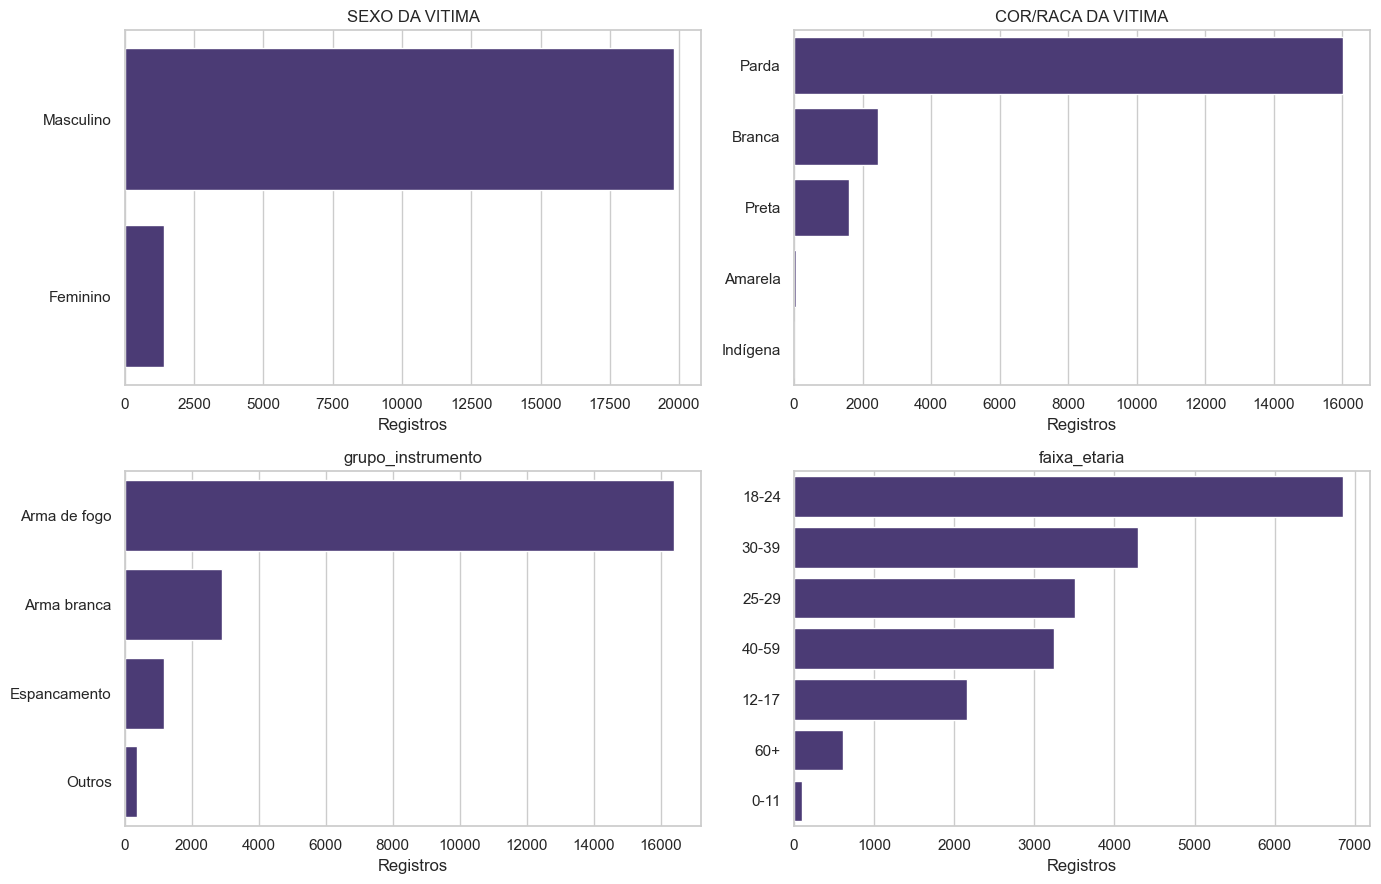

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
cols = ['SEXO DA VITIMA', 'COR/RACA DA VITIMA', 'grupo_instrumento', 'faixa_etaria']
for ax, col in zip(axes.ravel(), cols):
    ordem = df[col].value_counts().index
    sns.countplot(data=df, y=col, order=ordem, ax=ax)
    ax.set_title(col)
    ax.set_xlabel('Registros')
    ax.set_ylabel('')
plt.tight_layout()

## 6. Analise temporal

In [10]:
por_ano = df.groupby('ano').size().rename('registros').reset_index()
por_ano

,ano,registros
0,2012,2187
1,2013,2247
2,2014,2132
3,2015,1715
4,2016,1767
5,2017,1784
6,2018,1379
7,2019,1096
8,2020,1252
9,2021,1073


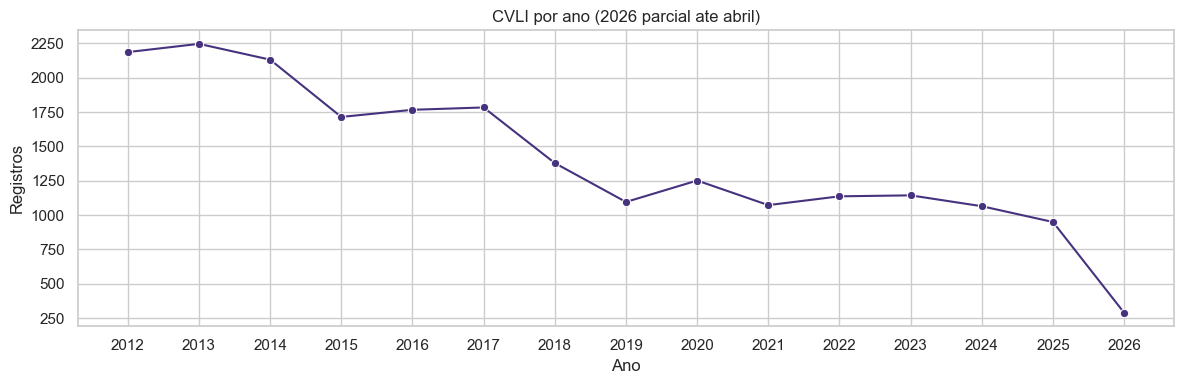

In [11]:
plt.figure(figsize=(12, 4))
sns.lineplot(data=por_ano, x='ano', y='registros', marker='o')
plt.title('CVLI por ano (2026 parcial ate abril)')
plt.xlabel('Ano')
plt.ylabel('Registros')
plt.xticks(por_ano['ano'])
plt.tight_layout()

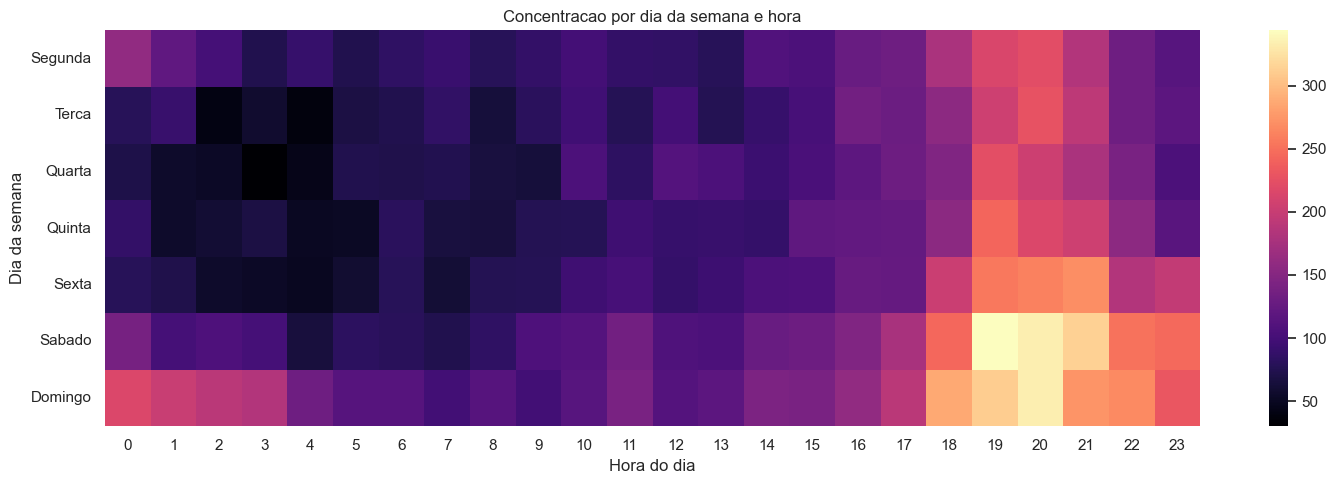

In [12]:
ordem_dias = ['Segunda', 'Terca', 'Quarta', 'Quinta', 'Sexta', 'Sabado', 'Domingo']
heat = (
    df.pivot_table(index='dia_semana', columns='hora', values='ID_CONTROLE', aggfunc='count')
    .reindex(ordem_dias)
    .fillna(0)
)

plt.figure(figsize=(15, 5))
sns.heatmap(heat, cmap='magma')
plt.title('Concentracao por dia da semana e hora')
plt.xlabel('Hora do dia')
plt.ylabel('Dia da semana')
plt.tight_layout()

In [13]:
tabela_freq('periodo_dia')

,n,percentual
periodo_dia,,
Noite (18-23),8968,42.27
Tarde (12-17),4871,22.96
Manha (6-11),3690,17.39
Madrugada (0-5),3688,17.38


## 7. Analise espacial simples

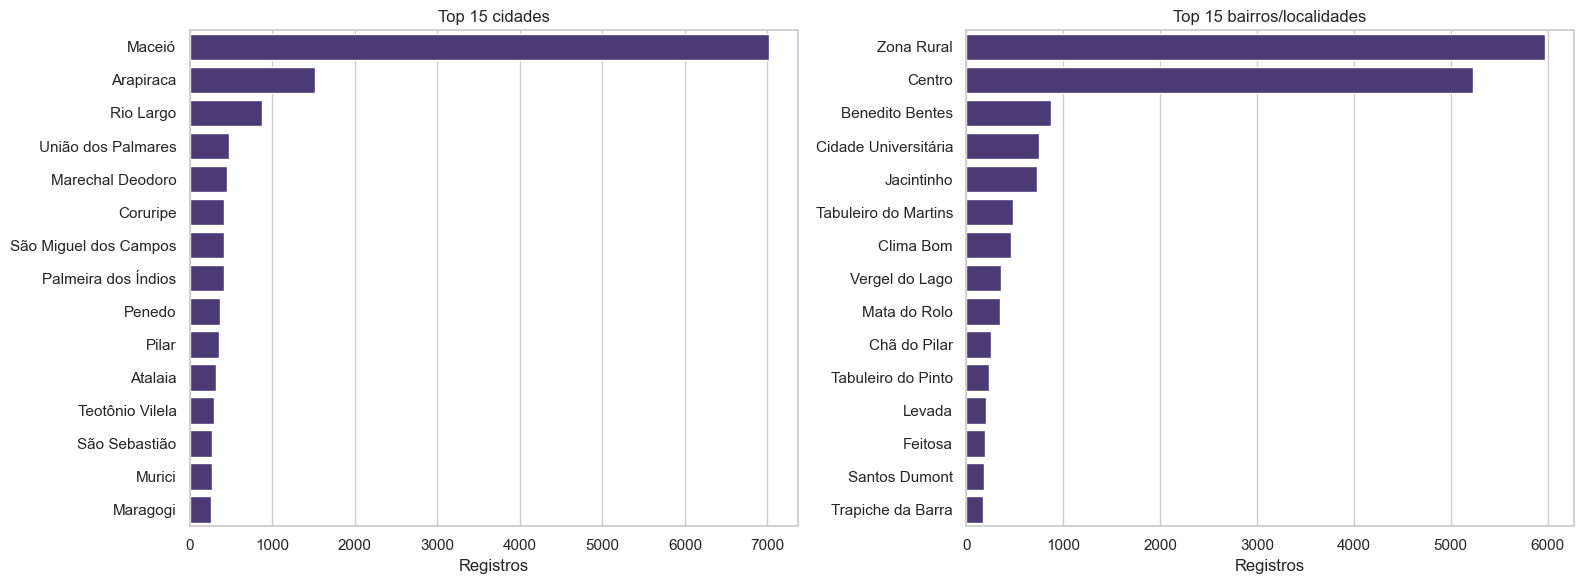

In [14]:
top_cidades = df['CIDADE DO FATO'].value_counts().head(15)
top_bairros = df['BAIRRO DO FATO'].value_counts().head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(x=top_cidades.values, y=top_cidades.index, ax=axes[0])
axes[0].set_title('Top 15 cidades')
axes[0].set_xlabel('Registros')
axes[0].set_ylabel('')

sns.barplot(x=top_bairros.values, y=top_bairros.index, ax=axes[1])
axes[1].set_title('Top 15 bairros/localidades')
axes[1].set_xlabel('Registros')
axes[1].set_ylabel('')
plt.tight_layout()

In [15]:
top_cidades_df = df['CIDADE DO FATO'].value_counts().head(10).rename_axis('cidade').reset_index(name='registros')
top_cidades_df['percentual'] = 100 * top_cidades_df['registros'] / len(df)
top_cidades_df.round(2)

,cidade,registros,percentual
0,Maceió,7013,33.05
1,Arapiraca,1517,7.15
2,Rio Largo,878,4.14
3,União dos Palmares,471,2.22
4,Marechal Deodoro,458,2.16
5,Coruripe,420,1.98
6,São Miguel dos Campos,418,1.97
7,Palmeira dos Índios,416,1.96
8,Penedo,366,1.73
9,Pilar,354,1.67


## 8. Cruzamentos das hipoteses iniciais

### H1: maioria das vitimas = homens jovens, pardos/pretos, baixa escolaridade

In [16]:
jovem_15_29 = df['idade'].between(15, 29)
parda_preta = df['COR/RACA DA VITIMA'].isin(['Parda', 'Preta'])
masculino = df['SEXO DA VITIMA'].eq('Masculino')

h1 = pd.Series({
    'Masculino (%)': masculino.mean() * 100,
    '15 a 29 anos (%)': jovem_15_29.mean() * 100,
    'Parda ou preta (%)': parda_preta.mean() * 100,
    'Masculino + 15 a 29 + parda/preta (%)': (masculino & jovem_15_29 & parda_preta).mean() * 100,
})
h1.round(2)

Masculino (%)                            93.34
15 a 29 anos (%)                         57.90
Parda ou preta (%)                       82.99
Masculino + 15 a 29 + parda/preta (%)    46.94
dtype: float64

In [17]:
perfil = pd.crosstab(
    [df['SEXO DA VITIMA'], df['faixa_etaria']],
    df['COR/RACA DA VITIMA'],
    normalize='all'
) * 100
perfil.round(2).sort_index()

COR/RACA DA VITIMA           Amarela  Branca  Indígena  Parda  Preta
SEXO DA VITIMA faixa_etaria                                         
Feminino       0-11             0.00    0.02      0.01   0.18   0.02
               12-17            0.00    0.09      0.00   0.55   0.02
               18-24            0.00    0.17      0.00   1.33   0.11
               25-29            0.00    0.13      0.00   0.76   0.07
               30-39            0.01    0.26      0.00   1.26   0.12
               40-59            0.01    0.22      0.00   1.01   0.12
               60+              0.00    0.06      0.00   0.21   0.02
Masculino      0-11             0.00    0.04      0.00   0.23   0.01
               12-17            0.04    0.72      0.00   8.37   0.60
               18-24            0.10    3.15      0.00  25.30   2.74
               25-29            0.07    1.85      0.02  12.45   1.50
               30-39            0.08    2.55      0.01  15.01   1.53
               40-59            0.06    2.35      0.01  10.89   0.99
               60+              0.00    0.64      0.01   1.86   0.14

### H2: pico em fim de semana e noite/madrugada

In [18]:
h2 = pd.Series({
    'Fim de semana (%)': df['fim_de_semana'].mean() * 100,
    'Noite ou madrugada (%)': df['periodo_dia'].isin(['Noite (18-23)', 'Madrugada (0-5)']).mean() * 100,
    'Fim de semana + noite/madrugada (%)': (
        df['fim_de_semana'] & df['periodo_dia'].isin(['Noite (18-23)', 'Madrugada (0-5)'])
    ).mean() * 100,
})
h2.round(2)

Fim de semana (%)                      37.66
Noite ou madrugada (%)                 59.65
Fim de semana + noite/madrugada (%)    23.88
dtype: float64

In [19]:
pd.crosstab(df['dia_semana'], df['periodo_dia']).reindex(ordem_dias)

periodo_dia,Madrugada (0-5),Manha (6-11),Tarde (12-17),Noite (18-23)
dia_semana,,,,
Segunda,618,527,639,1046
Terca,374,479,631,1031
Quarta,327,466,663,998
Quinta,373,461,635,1089
Sexta,366,490,646,1368
Sabado,594,590,795,1733
Domingo,1036,677,862,1703


### H3: arma de fogo domina e pesa em vias publicas/homens jovens

In [20]:
arma_fogo = df['grupo_instrumento'].eq('Arma de fogo')
h3 = pd.Series({
    'Arma de fogo no total (%)': arma_fogo.mean() * 100,
    'Arma de fogo entre homens 15-29 (%)': arma_fogo[masculino & jovem_15_29].mean() * 100,
    'Arma de fogo em espaco publico (%)': arma_fogo[df['grupo_local'].eq('Espaco publico')].mean() * 100,
})
h3.round(2)

Arma de fogo no total (%)              77.24
Arma de fogo entre homens 15-29 (%)    84.03
Arma de fogo em espaco publico (%)     79.39
dtype: float64

In [21]:
pd.crosstab(
    df['grupo_local'],
    df['grupo_instrumento'],
    normalize='index'
).mul(100).round(2).sort_values('Arma de fogo', ascending=False)

grupo_instrumento,Arma branca,Arma de fogo,Espancamento,Outros
grupo_local,,,,
Entorno de casa,10.82,84.57,4.04,0.57
Espaco publico,12.67,80.46,5.75,1.11
Outros,15.30,75.19,5.57,3.95
Ambiente interno,20.76,68.81,6.73,3.70
Area externa/isolada,18.91,68.38,9.68,3.03


### H4: arma branca/espancamento em ambientes internos e vitimas femininas

In [22]:
branca_esp = df['grupo_instrumento'].isin(['Arma branca', 'Espancamento'])
h4 = pd.Series({
    'Arma branca/espancamento no total (%)': branca_esp.mean() * 100,
    'Arma branca/espancamento entre mulheres (%)': branca_esp[df['SEXO DA VITIMA'].eq('Feminino')].mean() * 100,
    'Arma branca/espancamento em ambiente interno (%)': branca_esp[df['grupo_local'].eq('Ambiente interno')].mean() * 100,
})
h4.round(2)

Arma branca/espancamento no total (%)               19.23
Arma branca/espancamento entre mulheres (%)         35.22
Arma branca/espancamento em ambiente interno (%)    27.11
dtype: float64

In [23]:
pd.crosstab(
    [df['SEXO DA VITIMA'], df['grupo_local']],
    df['grupo_instrumento'],
    normalize='index'
).mul(100).round(2)

grupo_instrumento                    Arma branca  Arma de fogo  Espancamento  \
SEXO DA VITIMA grupo_local                                                     
Feminino       Ambiente interno            32.22         47.18         11.80   
               Area externa/isolada        15.79         45.61         22.81   
               Entorno de casa             25.48         65.87          5.29   
               Espaco publico              18.25         63.75         12.90   
               Outros                      19.49         63.56          7.63   
Masculino      Ambiente interno            18.36         73.35          5.66   
               Area externa/isolada        19.21         70.53          8.44   
               Entorno de casa             10.17         85.40          3.98   
               Espaco publico              12.43         81.17          5.45   
               Outros                      15.01         75.98          5.43   

grupo_instrumento                    Outros  
SEXO DA VITIMA grupo_local                   
Feminino       Ambiente interno        8.80  
               Area externa/isolada   15.79  
               Entorno de casa         3.37  
               Espaco publico          5.11  
               Outros                  9.32  
Masculino      Ambiente interno        2.63  
               Area externa/isolada    1.82  
               Entorno de casa         0.45  
               Espaco publico          0.94  
               Outros                  3.58

## 8.5 Testes de Hipótese Estatísticos — Qui-Quadrado

Para cada hipótese levantada, aplicamos o **teste qui-quadrado de independência (χ²)**
para verificar se a associação observada é estatisticamente significativa (p < 0.05)
ou se pode ser explicada pelo acaso.

> **Interpretação:** p-valor < 0.05 rejeita a hipótese nula de independência,
> confirmando que as variáveis estão associadas na população.


In [24]:
from scipy.stats import chi2_contingency

def teste_qui_quadrado(tabela_contingencia, nome_teste):
    chi2, p, dof, expected = chi2_contingency(tabela_contingencia)
    resultado = 'SIGNIFICATIVO (p < 0.05) ✓' if p < 0.05 else 'NÃO significativo (p >= 0.05)'
    print(f'--- {nome_teste} ---')
    print(f'  Chi2 = {chi2:.2f} | Graus de liberdade = {dof} | p-valor = {p:.2e}')
    print(f'  Resultado: {resultado}')
    print()
    return p

print('=== TESTES QUI-QUADRADO PARA AS HIPOTESES ===\n')

# H1: Sexo x faixa etaria (homens jovens sao maioria)
tab_h1 = pd.crosstab(df['SEXO DA VITIMA'], df['faixa_etaria'].astype(str))
p_h1 = teste_qui_quadrado(tab_h1, 'H1 — Sexo x Faixa Etaria')

# H1b: Cor/Raca x Sexo
tab_h1b = pd.crosstab(df['SEXO DA VITIMA'], df['COR/RACA DA VITIMA'])
p_h1b = teste_qui_quadrado(tab_h1b, 'H1 — Sexo x Cor/Raca')

# H2: fim de semana x periodo do dia
tab_h2 = pd.crosstab(df['fim_de_semana'].map({True:'Fim de semana', False:'Dia de semana'}),
                      df['periodo_dia'].astype(str))
p_h2 = teste_qui_quadrado(tab_h2, 'H2 — Dia da Semana x Periodo do Dia')

# H3: grupo_local x grupo_instrumento
tab_h3 = pd.crosstab(df['grupo_local'], df['grupo_instrumento'])
p_h3 = teste_qui_quadrado(tab_h3, 'H3 — Local do Fato x Instrumento')

# H4: sexo x grupo_instrumento (arma branca/espancamento em mulheres)
tab_h4 = pd.crosstab(df['SEXO DA VITIMA'], df['grupo_instrumento'])
p_h4 = teste_qui_quadrado(tab_h4, 'H4 — Sexo da Vitima x Instrumento')

print('=== RESUMO ===')
hipoteses = ['H1 (Sexo x Idade)', 'H1b (Sexo x Raca)', 'H2 (Semana x Hora)', 'H3 (Local x Instrumento)', 'H4 (Sexo x Instrumento)']
pvalores = [p_h1, p_h1b, p_h2, p_h3, p_h4]
for h, p in zip(hipoteses, pvalores):
    status = '✓ Confirmada' if p < 0.05 else '✗ Nao confirmada'
    print(f'  {h}: p={p:.2e} → {status}')


=== TESTES QUI-QUADRADO PARA AS HIPOTESES ===

--- H1 — Sexo x Faixa Etaria ---
  Chi2 = 320.56 | Graus de liberdade = 6 | p-valor = 3.20e-66
  Resultado: SIGNIFICATIVO (p < 0.05) ✓

--- H1 — Sexo x Cor/Raca ---
  Chi2 = 7.15 | Graus de liberdade = 4 | p-valor = 1.28e-01
  Resultado: NÃO significativo (p >= 0.05)

--- H2 — Dia da Semana x Periodo do Dia ---
  Chi2 = 113.66 | Graus de liberdade = 3 | p-valor = 1.79e-24
  Resultado: SIGNIFICATIVO (p < 0.05) ✓

--- H3 — Local do Fato x Instrumento ---
  Chi2 = 490.92 | Graus de liberdade = 12 | p-valor = 1.90e-97
  Resultado: SIGNIFICATIVO (p < 0.05) ✓

--- H4 — Sexo da Vitima x Instrumento ---
  Chi2 = 564.35 | Graus de liberdade = 3 | p-valor = 5.40e-122
  Resultado: SIGNIFICATIVO (p < 0.05) ✓

=== RESUMO ===
  H1 (Sexo x Idade): p=3.20e-66 → ✓ Confirmada
  H1b (Sexo x Raca): p=1.28e-01 → ✗ Nao confirmada
  H2 (Semana x Hora): p=1.79e-24 → ✓ Confirmada
  H3 (Local x Instrumento): p=1.90e-97 → ✓ Confirmada
  H4 (Sexo x Instrumento): p=5.

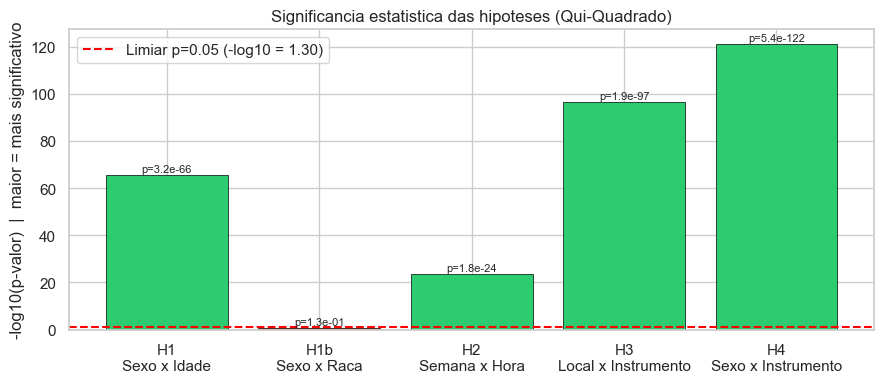

In [25]:
# Visualizacao dos p-valores
fig, ax = plt.subplots(figsize=(9, 4))
nomes = ['H1\nSexo x Idade', 'H1b\nSexo x Raca', 'H2\nSemana x Hora',
         'H3\nLocal x Instrumento', 'H4\nSexo x Instrumento']
pvals = [p_h1, p_h1b, p_h2, p_h3, p_h4]
cores = ['#2ecc71' if p < 0.05 else '#e74c3c' for p in pvals]
bars = ax.bar(nomes, [-np.log10(p) for p in pvals], color=cores, edgecolor='black', linewidth=0.5)
ax.axhline(-np.log10(0.05), color='red', linestyle='--', linewidth=1.5, label='Limiar p=0.05 (-log10 = 1.30)')
ax.set_ylabel('-log10(p-valor)  |  maior = mais significativo')
ax.set_title('Significancia estatistica das hipoteses (Qui-Quadrado)')
ax.legend()
for bar, p in zip(bars, pvals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'p={p:.1e}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()


## 9. Primeiras leituras para decisao

Use celulas acima para preencher estes insights com numeros do proprio notebook:

1. **Patrulhamento por territorio e horario:** priorizar cidades/bairros e faixas horarias com maior concentracao, avaliando reforco em `top_cidades`, `top_bairros` e heatmap dia-hora.
2. **Prevencao focada em perfil vulneravel:** se H1 permanecer forte, campanhas e acoes sociais devem mirar homens jovens em territorios com recorrencia alta.
3. **Resposta a armas de fogo:** se H3 confirmar participacao dominante de arma de fogo, recomendacao pode focar blitzes, inteligencia e controle de circulacao em rotas/bairros criticos.
4. **Violencia em ambiente domestico:** se H4 mostrar diferenca para mulheres/ambiente interno, separar analise de feminicidio e crimes domesticos.

## 10. Proximos passos tecnicos

- tratar `ESCOLARIDADE VITIMA` e `OCUPACAO VITIMA`: muitos faltantes, talvez usar so como variavel auxiliar;
- separar 2026 por ser ano parcial;
- testar associacoes com qui-quadrado para sexo x instrumento, local x instrumento, fim de semana x periodo;
- criar variavel alvo para classificacao: `grupo_instrumento`;
- avaliar clusterizacao de perfis com idade, sexo, raca, cidade, periodo e local;
- se houver shapefile ou coordenadas por municipio/bairro, evoluir para mapa.